# News Headline Scraper & Analyzer for German Energy

**Purpose:** Fetch German energy news headlines via NewsAPI.org, analyze with BERTopic, and refine keywords for production, consumption, and policy topics.

**Approach:** Start broad → Analyze topics → Manually refine keywords → Test combinations


## 1. Setup & Configuration


In [52]:
# Core libraries
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import time
from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')

# API imports
from newsapi import NewsApiClient

# Environment variables
import os
from dotenv import load_dotenv

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# BERTopic for topic modeling
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    bertopic_available = True
    print("✓ BERTopic and sentence-transformers imported successfully")
except ImportError:
    bertopic_available = False
    print("✗ BERTopic not found. Installing...")
    print("Please run: pip install bertopic sentence-transformers")

# Load environment variables from .env file
load_dotenv()

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("colorblind")

print("\n" + "="*60)
print("SETUP COMPLETE")
print("="*60)
print("✓ Core libraries imported successfully")
print(f"✓ Environment variables loaded from .env file")
if not bertopic_available:
    print("\n⚠️  Missing BERTopic - install with: pip install bertopic sentence-transformers")
print("="*60)


✓ BERTopic and sentence-transformers imported successfully

SETUP COMPLETE
✓ Core libraries imported successfully
✓ Environment variables loaded from .env file


In [53]:
# Configure date range: last 12 months
end_date = datetime.now()
start_date = end_date - timedelta(days=365)  # 12 months

print(f"Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(end_date - start_date).days}")

# Load NewsAPI key
NEWS_API_KEY = os.getenv('NEWSAPIORG_KEY')

if NEWS_API_KEY:
    print(f"✓ NewsAPI key loaded successfully")
else:
    print("⚠️  NEWSAPIORG_KEY not found in .env file")
    print("Please ensure your .env file contains: NEWSAPIORG_KEY=your_api_key_here")


Date range: 2024-10-26 to 2025-10-26
Total days: 365
✓ NewsAPI key loaded successfully


## 2. Data Fetching Function


In [ ]:
def fetch_news_data(start_date: str, end_date: str, keywords: str, api_key: str) -> pd.DataFrame:
    """
    Fetch German news articles from NewsAPI.org with flexible keywords.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    keywords : str
        Search keywords (German terms)
    api_key : str
        NewsAPI.org API key
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: 'publishedAt', 'title', 'description', 'source', 'url'
    """
    # Initialize NewsAPI.org client
    newsapi = NewsApiClient(api_key=api_key)
    
    # German news sources (same as reference notebook)
    SOURCES = 'bild, der-tagesspiegel,focus,handelsblatt,spiegel-online,wirtschafts-woche'
    
    print(f"Fetching articles from NewsAPI.org...")
    print(f"Keywords: {keywords}")
    print(f"Sources: {SOURCES}")
    print(f"Date range: {start_date} to {end_date}")
    
    try:
        # Calculate date ranges - fetch in weekly increments
        today = datetime.strptime(end_date, '%Y-%m-%d')
        start = datetime.strptime(start_date, '%Y-%m-%d')
        all_articles = []
        
        # Calculate number of weekly periods needed
        total_days = (today - start).days
        num_periods = (total_days // 7) + (1 if total_days % 7 > 0 else 0)
        
        for period in range(num_periods):
            # Calculate 'to' date (end of weekly period)
            to_date = today - timedelta(days=period * 7)
            # Calculate 'from' date (start of weekly period)
            from_date = to_date - timedelta(days=7)
            
            # Format dates for API (ISO 8601 format)
            from_str = from_date.strftime('%Y-%m-%d')
            to_str = to_date.strftime('%Y-%m-%d')
            
            print(f"Period {period + 1}/{num_periods}: {from_str} to {to_str}")
            
            # Fetch articles for this period
            articles_period = newsapi.get_everything(
                q=keywords,
                sources=SOURCES,
                language='de',
                sort_by='publishedAt',
                from_param=from_str,
                to=to_str,
                page_size=100
            )
            
            print(f"  Total results available: {articles_period['totalResults']}")
            print(f"  Articles retrieved: {len(articles_period['articles'])}")
            
            # Add articles to list
            all_articles.extend(articles_period['articles'])
        
        # Convert all articles to DataFrame
        if not all_articles:
            print("Warning: No articles fetched!")
            return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])
        
        news_df = pd.DataFrame([
            {
                'publishedAt': article['publishedAt'],
                'title': article.get('title', ''),
                'description': article.get('description', ''),
                'source': article['source']['name'],
                'url': article.get('url', '')
            }
            for article in all_articles
        ])
        
        print(f"\n✓ Initial articles collected: {len(news_df)}")
        
        # Enhanced duplicate removal (from reference notebook)
        if not news_df.empty and 'title' in news_df.columns:
            initial_count = len(news_df)
            
            # Check for completely empty or null titles
            empty_titles = news_df['title'].isna() | (news_df['title'].str.strip() == '')
            if empty_titles.any():
                print(f"  ⚠️  Found {empty_titles.sum()} articles with empty titles (will be removed)")
                news_df = news_df[~empty_titles]
            
            # Remove exact title duplicates (keeps first occurrence by date)
            news_df = news_df.sort_values('publishedAt')
            news_df = news_df.drop_duplicates(subset=['title'], keep='first')
            duplicates_removed = initial_count - len(news_df)
            
            if duplicates_removed > 0:
                print(f"  ✓ Removed {duplicates_removed} duplicate/empty articles")
                print(f"  ✓ Kept {len(news_df)} unique articles")
            else:
                print(f"  ✓ No duplicates found - all {len(news_df)} articles are unique")
        
        # Parse dates
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        
        # Filter out articles with exclusion terms
        if not news_df.empty:
            exclusion_terms = [
                "fußball", "bundesliga", "sport", "cottbus", "energie cottbus",
                "campino", "musik", "konzert", "festival",
                "liebeserklärung", "poetry", "lyrik",
                "vettel", "formel", "rennsport",
                "jetzt lesen", "hier finden", "informationen", "thema"
            ]
            
            def contains_exclusion_term(text):
                if pd.isna(text):
                    return False
                text_lower = str(text).lower()
                return any(term in text_lower for term in exclusion_terms)
            
            # Filter out articles with exclusion terms in title or description
            before_filter = len(news_df)
            exclusion_mask = (
                news_df['title'].apply(contains_exclusion_term) |
                news_df['description'].apply(contains_exclusion_term)
            )
            news_df = news_df[~exclusion_mask]
            filtered_count = before_filter - len(news_df)
            
            if filtered_count > 0:
                print(f"  ✓ Filtered out {filtered_count} articles with exclusion terms")
                print(f"  ✓ Kept {len(news_df)} relevant articles")
            else:
                print(f"  ✓ No articles filtered out - all {len(news_df)} articles are relevant")
        
        print(f"\n{'='*60}")
        print(f"✓ DataFrame created with shape: {news_df.shape}")
        print(f"✓ Total unique articles retrieved: {len(news_df)}")
        print(f"✓ Date range: {news_df['publishedAt'].min()} to {news_df['publishedAt'].max()}")
        print(f"{'='*60}")
        
        return news_df
        
    except Exception as e:
        print(f"✗ Error: {e}")
        return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])

print("✓ News fetching function defined")


✓ News fetching function defined


## 3. Initial Broad Data Fetch


In [63]:
# Define refined German keyword set focusing on energy infrastructure and policy
# Exclude sports teams, entertainment, and generic content by using more specific terms
BROAD_KEYWORDS = (
    '"Energiewende" OR "Stromversorgung" OR "Energieversorgung" OR '
    '"Stromerzeugung" OR "Energieerzeugung" OR "Strompreis" OR '
    '"Energiepreis" OR "Stromverbrauch" OR "Energieverbrauch" OR '
    '"Kraftwerk" OR "Erneuerbare Energien" OR "Atomkraft" OR '
    '"Kohlekraftwerk" OR "Gaskraftwerk" OR "Windkraft" OR "Solar" OR '
    '"Energiepolitik" OR "Strommarkt" OR "Energienetz" OR "Stromnetz"'
)

print("Broad keywords defined:")
print(BROAD_KEYWORDS)

# Define exclusion terms to filter out irrelevant content
EXCLUSION_TERMS = [
    "fußball", "bundesliga", "sport", "cottbus", "energie cottbus",  # Sports teams
    "campino", "musik", "konzert", "festival",  # Entertainment
    "liebeserklärung", "poetry", "lyrik",  # Arts/culture
    "vettel", "formel", "rennsport",  # Motorsports
    "jetzt lesen", "hier finden", "informationen", "thema"  # Generic news phrases
]

print(f"\nExclusion terms defined: {len(EXCLUSION_TERMS)} terms")
print("Exclusion terms:", ", ".join(EXCLUSION_TERMS[:10]) + "..." if len(EXCLUSION_TERMS) > 10 else ", ".join(EXCLUSION_TERMS))

# Fetch broad dataset if API key is available
if NEWS_API_KEY:
    print(f"\nFetching broad dataset...")
    broad_news_df = fetch_news_data(
        start_date.strftime('%Y-%m-%d'),
        end_date.strftime('%Y-%m-%d'),
        BROAD_KEYWORDS,
        NEWS_API_KEY
    )
    
else:
    print("⚠️  Cannot fetch data without NewsAPI key")
    # Create placeholder for development
    broad_news_df = pd.DataFrame({
        'publishedAt': pd.date_range(start=start_date, end=end_date, freq='D'),
        'title': ['Sample energy headline ' + str(i) for i in range(365)],
        'description': ['Sample description for headline ' + str(i) for i in range(365)],
        'source': ['Focus'] * 365,
        'url': ['https://example.com/' + str(i) for i in range(365)]
    })
    print(f"Created placeholder dataset: {len(broad_news_df)} articles")


Broad keywords defined:
"Energiewende" OR "Stromversorgung" OR "Energieversorgung" OR "Stromerzeugung" OR "Energieerzeugung" OR "Strompreis" OR "Energiepreis" OR "Stromverbrauch" OR "Energieverbrauch" OR "Kraftwerk" OR "Erneuerbare Energien" OR "Atomkraft" OR "Kohlekraftwerk" OR "Gaskraftwerk" OR "Windkraft" OR "Solar" OR "Energiepolitik" OR "Strommarkt" OR "Energienetz" OR "Stromnetz"

Exclusion terms defined: 19 terms
Exclusion terms: fußball, bundesliga, sport, cottbus, energie cottbus, campino, musik, konzert, festival, liebeserklärung...

Fetching broad dataset...
Fetching articles from NewsAPI.org...
Keywords: "Energiewende" OR "Stromversorgung" OR "Energieversorgung" OR "Stromerzeugung" OR "Energieerzeugung" OR "Strompreis" OR "Energiepreis" OR "Stromverbrauch" OR "Energieverbrauch" OR "Kraftwerk" OR "Erneuerbare Energien" OR "Atomkraft" OR "Kohlekraftwerk" OR "Gaskraftwerk" OR "Windkraft" OR "Solar" OR "Energiepolitik" OR "Strommarkt" OR "Energienetz" OR "Stromnetz"
Sources: bi

## 4. Initial Visualization Suite


### 4.1 Article Count Analysis


ARTICLE COUNT ANALYSIS
Total articles retrieved: 3382
Date range: 2024-10-20 05:13:20+00:00 to 2025-10-26 04:37:16+00:00
Average articles per day: 9.1

Top sources:
  Der Tagesspiegel: 1524 articles (45.1%)
  Focus: 1363 articles (40.3%)
  Bild: 495 articles (14.6%)


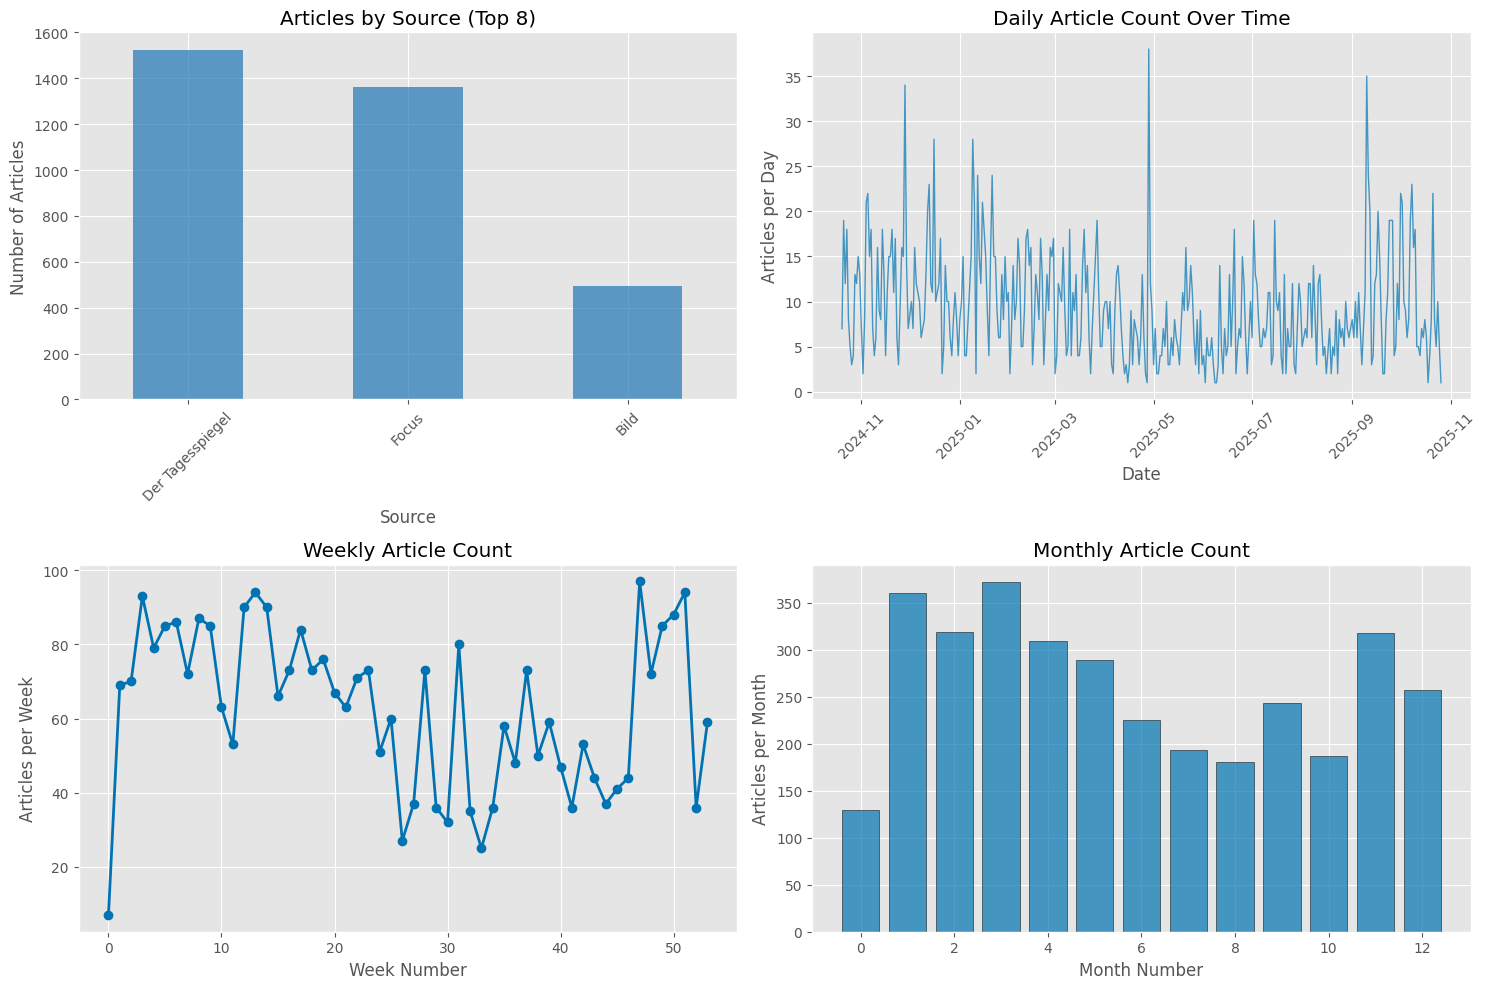


Temporal patterns:
  Peak daily count: 38 articles
  Average daily count: 9.5 articles
  Peak weekly count: 97 articles
  Average weekly count: 62.6 articles


In [64]:
# Summary statistics
print("="*60)
print("ARTICLE COUNT ANALYSIS")
print("="*60)
print(f"Total articles retrieved: {len(broad_news_df)}")
print(f"Date range: {broad_news_df['publishedAt'].min()} to {broad_news_df['publishedAt'].max()}")
print(f"Average articles per day: {len(broad_news_df) / ((broad_news_df['publishedAt'].max() - broad_news_df['publishedAt'].min()).days):.1f}")

# Source distribution
source_counts = broad_news_df['source'].value_counts()
print(f"\nTop sources:")
for source, count in source_counts.head(5).items():
    print(f"  {source}: {count} articles ({count/len(broad_news_df)*100:.1f}%)")

# Time series analysis
broad_news_df['date'] = broad_news_df['publishedAt'].dt.date
daily_counts = broad_news_df.groupby('date').size()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Source distribution
source_counts.head(8).plot(kind='bar', ax=axes[0,0], color='#1f77b4', alpha=0.7)
axes[0,0].set_title('Articles by Source (Top 8)')
axes[0,0].set_xlabel('Source')
axes[0,0].set_ylabel('Number of Articles')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Time series - daily counts
axes[0,1].plot(daily_counts.index, daily_counts.values, linewidth=1, alpha=0.7)
axes[0,1].set_title('Daily Article Count Over Time')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Articles per Day')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Weekly aggregation
weekly_counts = broad_news_df.groupby(broad_news_df['publishedAt'].dt.to_period('W')).size()
axes[1,0].plot(range(len(weekly_counts)), weekly_counts.values, marker='o', linewidth=2)
axes[1,0].set_title('Weekly Article Count')
axes[1,0].set_xlabel('Week Number')
axes[1,0].set_ylabel('Articles per Week')

# 4. Monthly aggregation
monthly_counts = broad_news_df.groupby(broad_news_df['publishedAt'].dt.to_period('M')).size()
axes[1,1].bar(range(len(monthly_counts)), monthly_counts.values, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Monthly Article Count')
axes[1,1].set_xlabel('Month Number')
axes[1,1].set_ylabel('Articles per Month')

plt.tight_layout()
plt.show()

print(f"\nTemporal patterns:")
print(f"  Peak daily count: {daily_counts.max()} articles")
print(f"  Average daily count: {daily_counts.mean():.1f} articles")
print(f"  Peak weekly count: {weekly_counts.max()} articles")
print(f"  Average weekly count: {weekly_counts.mean():.1f} articles")


### 4.2 Content Analysis

CONTENT ANALYSIS
Total words analyzed: 73997
Unique words: 15934

Top 20 most frequent words:
  deutschland: 507
  ukraine: 333
  strom: 330
  trump: 309
  focus: 233
  energiewende: 229
  berlin: 229
  merz: 228
  energie: 179
  habeck: 179
  euro: 177
  cdu: 176
  spd: 175
  deutsche: 172
  berliner: 164
  stromausfall: 163
  regierung: 159
  grünen: 153
  wirtschaft: 152
  politik: 151


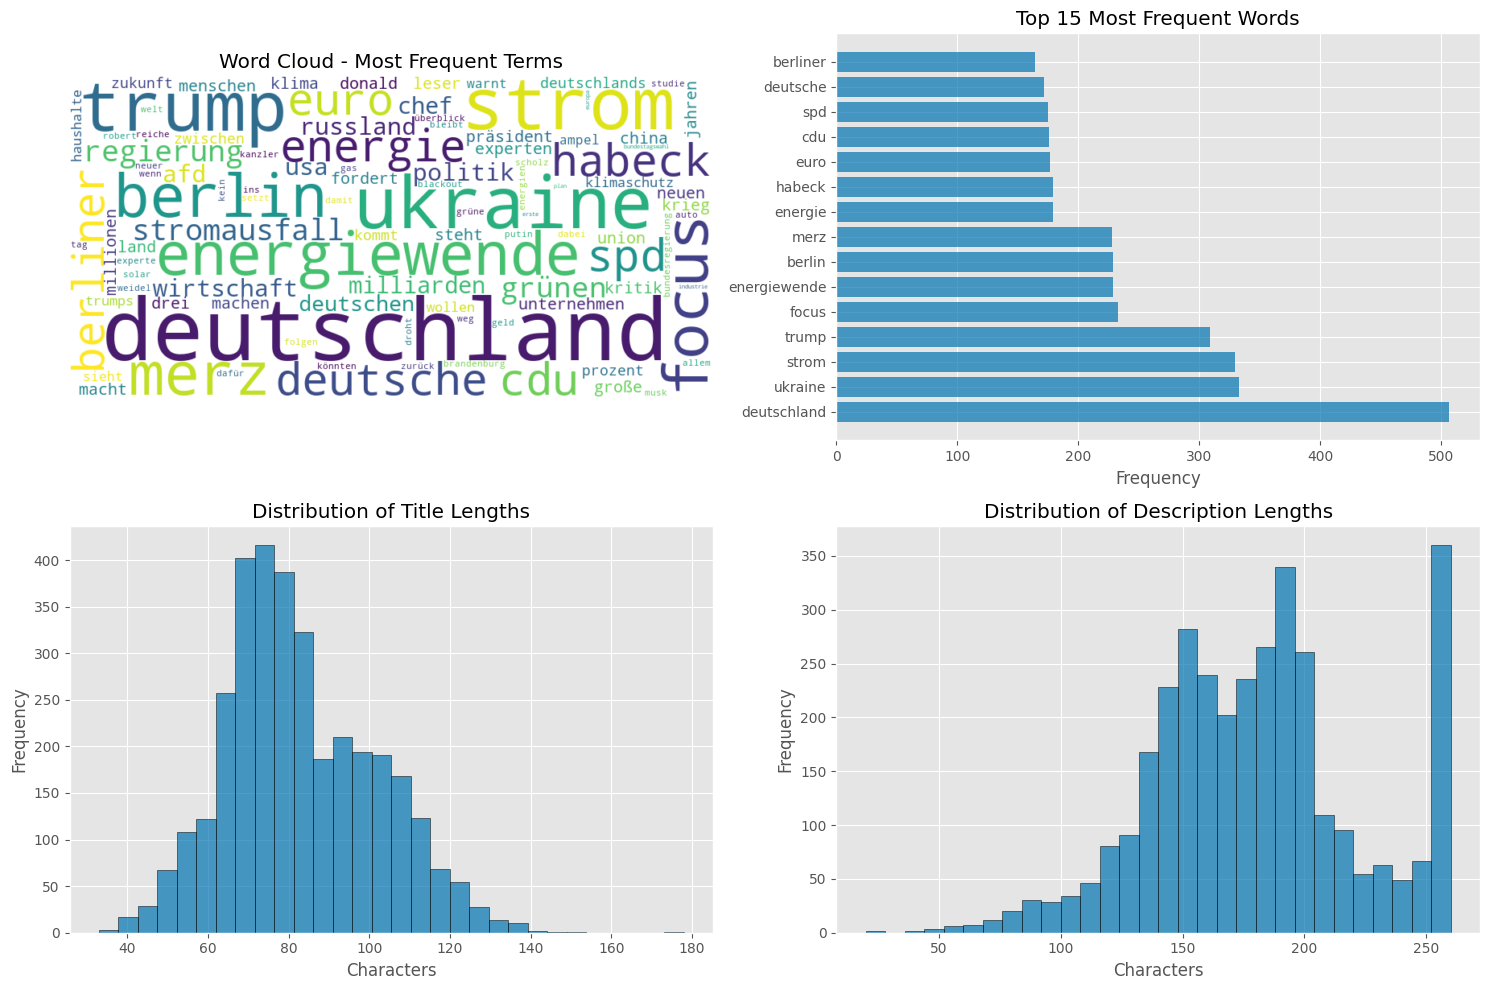


Text statistics:
  Average title length: 82.8 characters
  Average description length: 179.7 characters


In [65]:
# Combine all text for analysis
all_text = ' '.join(broad_news_df['title'].fillna('') + ' ' + broad_news_df['description'].fillna(''))

# German stopwords (basic set)
german_stopwords = {
    'der', 'die', 'das', 'und', 'oder', 'aber', 'mit', 'von', 'zu', 'in', 'auf', 'für', 'an', 'ist', 'sind', 
    'war', 'wurde', 'werden', 'kann', 'können', 'muss', 'müssen', 'soll', 'sollen', 'hat', 'haben', 'nach',
    'über', 'unter', 'bei', 'durch', 'gegen', 'ohne', 'um', 'bis', 'seit', 'während', 'trotz', 'wegen',
    'ein', 'eine', 'einen', 'einer', 'einem', 'eines', 'nicht', 'nur', 'auch', 'noch', 'schon', 'erst',
    'mehr', 'weniger', 'viel', 'wenig', 'alle', 'jeder', 'jede', 'jedes', 'manche', 'einige', 'keine',
    'dieser', 'diese', 'dieses', 'jener', 'jene', 'jenes', 'welcher', 'welche', 'welches', 'was', 'wer',
    'wie', 'wo', 'wann', 'warum', 'weshalb', 'wozu', 'wofür', 'womit', 'wovon', 'wozu', 'wodurch',
    "sie", "dem", "jetzt", "hier", "den", "lesen", "finden", "thema", "sich", "aus", "vor", "als", "des",
    "wird", "zum", "neue", "vom", "doch", "will", "nun", "beim","gibt", "ihre", "wieder", "geht", "zur",
    "sein", "ihr", "zwei", "zeigt", "immer", "seine", "viele", "online", "könnte", "woche","jahr", "wir"
    "neuen", "weiter", "dass", "wir"
}

# Clean and tokenize text
def clean_text(text):
    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-ZäöüßÄÖÜ\s]', ' ', text.lower())
    # Split into words and filter
    words = [word for word in text.split() if len(word) > 2 and word not in german_stopwords]
    return words

words = clean_text(all_text)
word_freq = Counter(words)

print("="*60)
print("CONTENT ANALYSIS")
print("="*60)
print(f"Total words analyzed: {len(words)}")
print(f"Unique words: {len(word_freq)}")

# Top words
print(f"\nTop 20 most frequent words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Word cloud
if len(word_freq) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                         max_words=100, colormap='viridis').generate_from_frequencies(word_freq)
    axes[0,0].imshow(wordcloud, interpolation='bilinear')
    axes[0,0].axis('off')
    axes[0,0].set_title('Word Cloud - Most Frequent Terms')

# 2. Top words bar chart
top_words = dict(word_freq.most_common(15))
axes[0,1].barh(range(len(top_words)), list(top_words.values()), alpha=0.7)
axes[0,1].set_yticks(range(len(top_words)))
axes[0,1].set_yticklabels(list(top_words.keys()))
axes[0,1].set_title('Top 15 Most Frequent Words')
axes[0,1].set_xlabel('Frequency')

# 3. Title length distribution
title_lengths = broad_news_df['title'].str.len()
axes[1,0].hist(title_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[1,0].set_title('Distribution of Title Lengths')
axes[1,0].set_xlabel('Characters')
axes[1,0].set_ylabel('Frequency')

# 4. Description length distribution
desc_lengths = broad_news_df['description'].str.len()
axes[1,1].hist(desc_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution of Description Lengths')
axes[1,1].set_xlabel('Characters')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nText statistics:")
print(f"  Average title length: {title_lengths.mean():.1f} characters")
print(f"  Average description length: {desc_lengths.mean():.1f} characters")


WORD SOURCE ANALYSIS: 'trump'
✓ Found 415 total occurrences of 'trump'
✓ Found in 3 different sources

📊 SOURCE FREQUENCY RANKING:
------------------------------------------------------------
 1. Focus                 225 occurrences ( 54.2%)
 2. Der Tagesspiegel      158 occurrences ( 38.1%)
 3. Bild                   32 occurrences (  7.7%)

📰 EXAMPLE HEADLINES BY SOURCE:
------------------------------------------------------------

🔸 Focus (225 occurrences):
   • [2024-10-21] 90.000 Dollar möglich - Trump gegen Harris – Duell um Bitcoin im US-Wahlkampf
   • [2024-11-01] US-Wahl und Börse - Trump vs. Harris: Welche Rolle spielt die US-Präsidentschaftswahl für die Börse?
   • [2024-11-01] Ukraine-Hilfen, Wirtschaft, Klima - Was der Ausgang der US-Wahl für Deutschland bedeuten könnte

🔸 Der Tagesspiegel (158 occurrences):
   • [2024-10-23] „Sie haben sich fast selbst zerstört“: Trump ätzt gegen Wind- und Solarkraft in Deutschland
   • [2024-11-04] Weltwirtschaft: Firmen haben Sorge vor

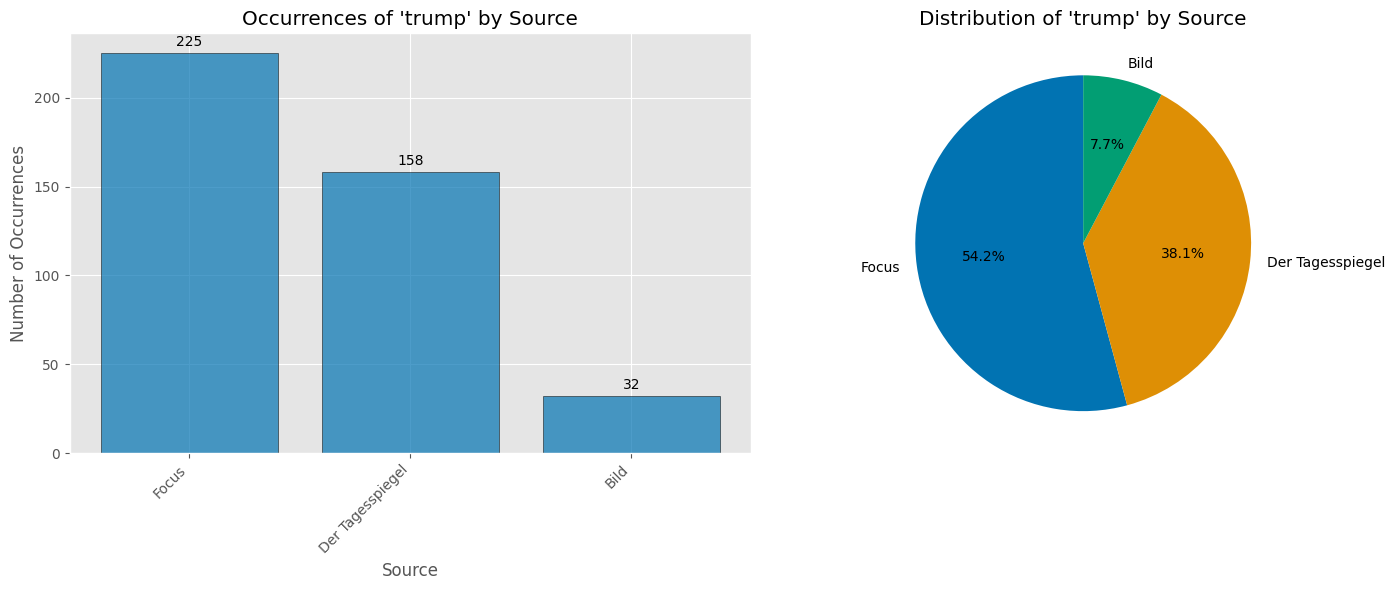

{'word': 'trump',
 'total_matches': 415,
 'source_counts': {'Focus': 225, 'Der Tagesspiegel': 158, 'Bild': 32},
 'source_examples': {'Focus': [{'title': '90.000 Dollar möglich - Trump gegen Harris – Duell um Bitcoin im US-Wahlkampf',
    'date': '2024-10-21',
    'matches': 1},
   {'title': 'US-Wahl und Börse - Trump vs. Harris: Welche Rolle spielt die US-Präsidentschaftswahl für die Börse?',
    'date': '2024-11-01',
    'matches': 3},
   {'title': 'Ukraine-Hilfen, Wirtschaft, Klima - Was der Ausgang der US-Wahl für Deutschland bedeuten könnte',
    'date': '2024-11-01',
    'matches': 1}],
  'Der Tagesspiegel': [{'title': '„Sie haben sich fast selbst zerstört“: Trump ätzt gegen Wind- und Solarkraft in Deutschland',
    'date': '2024-10-23',
    'matches': 2},
   {'title': 'Weltwirtschaft: Firmen haben Sorge vor Handelsbarrieren bei Sieg von Trump',
    'date': '2024-11-04',
    'matches': 1},
   {'title': '„Eine Gefährdung in der Substanz“: Was der Wahlsieg Trumps für den Klimaschutz

In [67]:
### 4.3 Word Source Analysis Tool

def analyze_word_by_source(word_to_search, case_sensitive=False):
    """
    Analyze which sources contain a specific word most frequently.
    
    Parameters:
    -----------
    word_to_search : str
        The word to search for in headlines and descriptions
    case_sensitive : bool, default False
        Whether the search should be case-sensitive
    
    Returns:
    --------
    dict: Analysis results with source counts and examples
    """
    print("="*60)
    print(f"WORD SOURCE ANALYSIS: '{word_to_search}'")
    print("="*60)
    
    # Prepare search parameters
    search_word = word_to_search if case_sensitive else word_to_search.lower()
    
    # Initialize counters
    source_counts = {}
    source_examples = {}
    total_matches = 0
    
    # Search through all articles
    for idx, row in broad_news_df.iterrows():
        source = row['source']
        
        # Combine title and description for search
        text_to_search = str(row['title']) + ' ' + str(row['description'] or '')
        
        # Apply case sensitivity
        if not case_sensitive:
            text_to_search = text_to_search.lower()
        
        # Count occurrences in this article
        matches_in_article = text_to_search.count(search_word)
        
        if matches_in_article > 0:
            total_matches += matches_in_article
            
            # Update source counts
            if source not in source_counts:
                source_counts[source] = 0
                source_examples[source] = []
            
            source_counts[source] += matches_in_article
            
            # Store example headlines (up to 3 per source)
            if len(source_examples[source]) < 3:
                source_examples[source].append({
                    'title': row['title'],
                    'date': row['publishedAt'].strftime('%Y-%m-%d'),
                    'matches': matches_in_article
                })
    
    # Display results
    if total_matches == 0:
        print(f"❌ No matches found for '{word_to_search}'")
        return None
    
    print(f"✓ Found {total_matches} total occurrences of '{word_to_search}'")
    print(f"✓ Found in {len(source_counts)} different sources")
    
    # Sort sources by frequency
    sorted_sources = sorted(source_counts.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n📊 SOURCE FREQUENCY RANKING:")
    print("-" * 60)
    for i, (source, count) in enumerate(sorted_sources, 1):
        percentage = (count / total_matches) * 100
        print(f"{i:2d}. {source:<20} {count:4d} occurrences ({percentage:5.1f}%)")
    
    # Show examples from top sources
    print(f"\n📰 EXAMPLE HEADLINES BY SOURCE:")
    print("-" * 60)
    for source, count in sorted_sources[:5]:  # Top 5 sources
        print(f"\n🔸 {source} ({count} occurrences):")
        for example in source_examples[source]:
            print(f"   • [{example['date']}] {example['title']}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Source frequency bar chart
    sources = [item[0] for item in sorted_sources]
    counts = [item[1] for item in sorted_sources]
    
    bars = axes[0].bar(range(len(sources)), counts, alpha=0.7, edgecolor='black')
    axes[0].set_title(f"Occurrences of '{word_to_search}' by Source")
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Number of Occurrences')
    axes[0].set_xticks(range(len(sources)))
    axes[0].set_xticklabels(sources, rotation=45, ha='right')
    
    # Add count labels on bars
    for i, count in enumerate(counts):
        axes[0].text(i, count + max(counts)*0.01, str(count), ha='center', va='bottom')
    
    # 2. Percentage pie chart
    if len(sources) > 1:
        axes[1].pie(counts, labels=sources, autopct='%1.1f%%', startangle=90)
        axes[1].set_title(f"Distribution of '{word_to_search}' by Source")
    else:
        axes[1].text(0.5, 0.5, f"Only found in\n{sources[0]}", 
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
        axes[1].set_title(f"Distribution of '{word_to_search}' by Source")
    
    plt.tight_layout()
    plt.show()
    
    # Return analysis results
    return {
        'word': word_to_search,
        'total_matches': total_matches,
        'source_counts': dict(sorted_sources),
        'source_examples': source_examples,
        'num_sources': len(source_counts)
    }

# Interactive function for easy word checking
def check_word(word):
    """
    Quick function to check a word's distribution across sources.
    Usage: check_word("Energie") or check_word("Solar")
    """
    return analyze_word_by_source("trump")

check_word("strom")


## 5. BERTopic Analysis for Topic Discovery


2025-10-26 17:05:18,973 - BERTopic - Embedding - Transforming documents to embeddings.


BERTOPIC ANALYSIS (WORKING VERSION)
Prepared 3382 documents for topic modeling
Initializing BERTopic with German language model...
Fitting BERTopic model...


Batches: 100%|██████████| 106/106 [00:06<00:00, 16.41it/s]
2025-10-26 17:05:29,171 - BERTopic - Embedding - Completed ✓
2025-10-26 17:05:29,171 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-26 17:05:36,148 - BERTopic - Dimensionality - Completed ✓
2025-10-26 17:05:36,149 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-26 17:05:36,648 - BERTopic - Cluster - Completed ✓
2025-10-26 17:05:36,651 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-26 17:05:36,739 - BERTopic - Representation - Completed ✓



✓ BERTopic analysis complete!
✓ Discovered 81 topics

Topic Overview:
------------------------------------------------------------
Topic -1:  862 documents - -1_die_der_und_in
Topic  0:  268 documents - 0_ukraine_russland_krieg_putin
Topic  1:  140 documents - 1_eu_klimaschutz_klima_co2
Topic  2:   90 documents - 2_berlin_berliner_40_und
Topic  3:   80 documents - 3_atomkraft_atomausstieg_atommüll_atomkraftwerke
Topic  4:   79 documents - 4_windräder_windkraft_windkraftanlagen_windenergie
Topic  5:   71 documents - 5_stromausfall_brandanschlag_südosten_berlin
Topic  6:   71 documents - 6_auto_autos_verbrenner_suv
Topic  7:   58 documents - 7_wirtschaft_deutsche_deutschland_konjunktur
Topic  8:   45 documents - 8_drohnen_absturz_ermittler_flughafen
Topic  9:   41 documents - 9_habeck_robert_grünen_baerbock
Topic 10:   41 documents - 10_spanien_blackout_portugal_halbinsel
Topic 11:   39 documents - 11_trump_präsident_us_donald
Topic 12:   39 documents - 12_trumps_baku_pariser_weltklimak

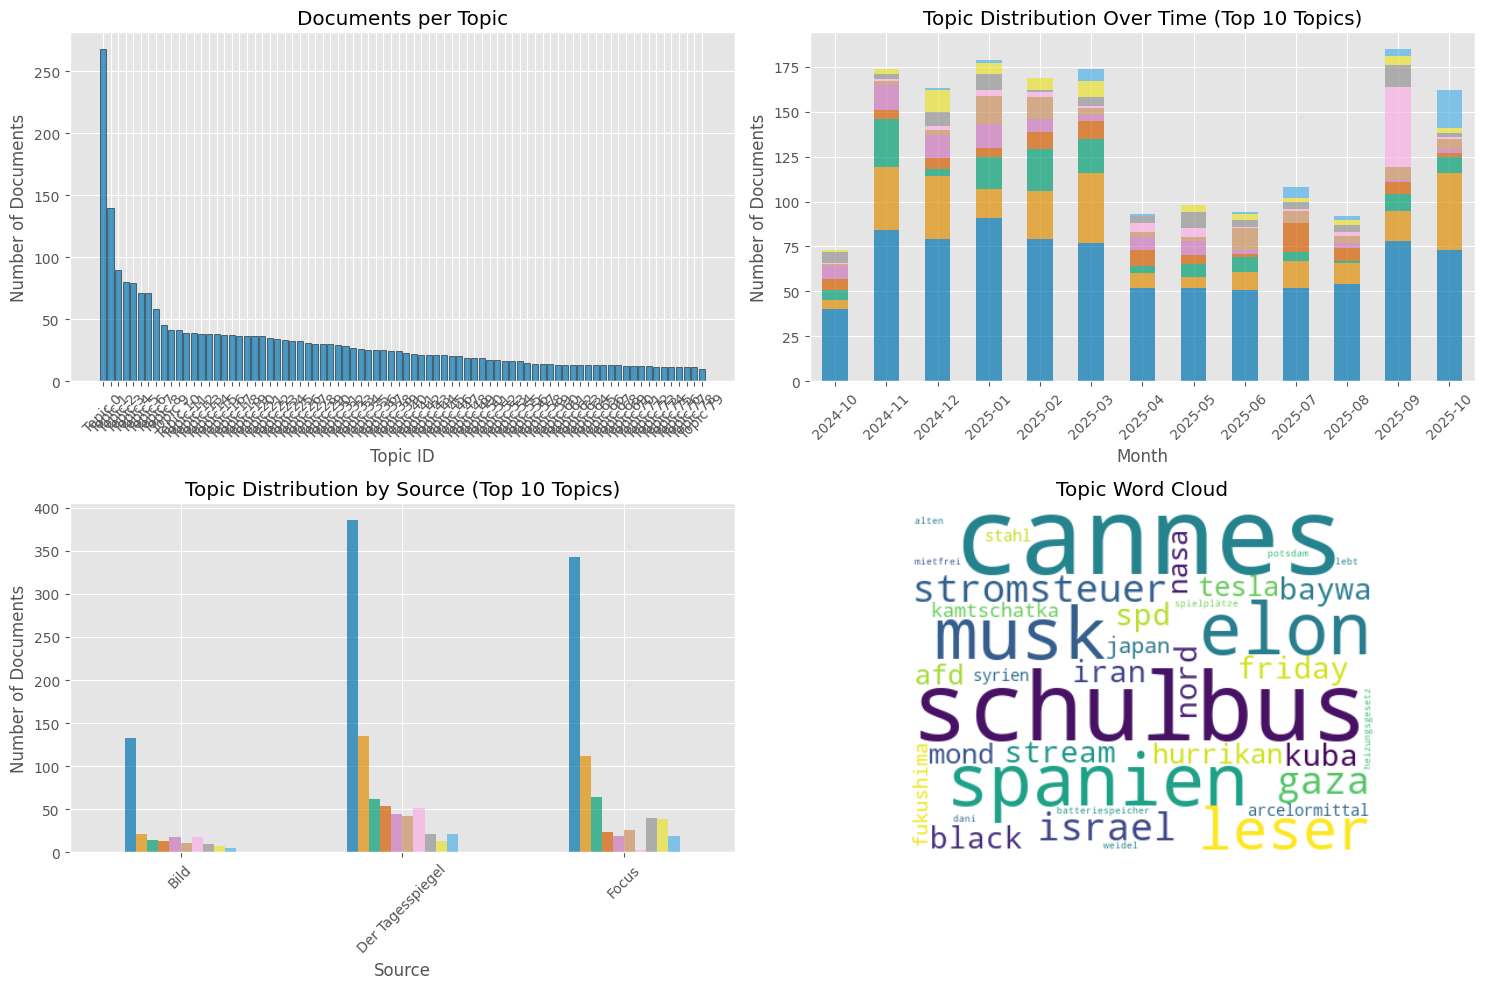


✓ BERTopic analysis complete!
✓ Use the topic information above to identify relevant topics for:
  - Energy production (Kraftwerk, Solar, Wind, etc.)
  - Energy consumption (Verbrauch, Bedarf, etc.)
  - Energy policy/pricing (Preis, Politik, etc.)


In [68]:
# ✅ WORKING BERTopic Analysis - Use This Cell Instead!
if bertopic_available and len(broad_news_df) > 0:
    print("="*60)
    print("BERTOPIC ANALYSIS (WORKING VERSION)")
    print("="*60)
    
    # Prepare documents for BERTopic
    documents = []
    for idx, row in broad_news_df.iterrows():
        # Combine title and description
        doc = str(row['title'])
        if pd.notna(row['description']) and len(str(row['description'])) > 0:
            doc += " " + str(row['description'])
        documents.append(doc)
    
    print(f"Prepared {len(documents)} documents for topic modeling")
    
    # Initialize BERTopic with German-compatible model
    print("Initializing BERTopic with German language model...")
    model = BERTopic(
        embedding_model="paraphrase-multilingual-MiniLM-L12-v2",
        language="german",
        calculate_probabilities=True,
        verbose=True
    )
    
    # Fit the model
    print("Fitting BERTopic model...")
    topics, probs = model.fit_transform(documents)
    
    # Get topic information
    topic_info = model.get_topic_info()
    print(f"\n✓ BERTopic analysis complete!")
    print(f"✓ Discovered {len(topic_info)} topics")
    
    # Display topic information
    print(f"\nTopic Overview:")
    print("-" * 60)
    for idx, row in topic_info.iterrows():
        print(f"Topic {row['Topic']:2d}: {row['Count']:4d} documents - {row['Name']}")
    
    # Show detailed topics - FIXED VERSION
    print(f"\nDetailed Topic Analysis:")
    print("=" * 60)
    
    # Get unique topic IDs from the topics array
    unique_topics = np.unique(topics)
    print(f"Unique topics found: {unique_topics}")
    
    for topic_id in unique_topics:
        if topic_id == -1:  # Skip outlier topic
            continue
            
        print(f"\nTopic {topic_id}:")
        print("-" * 40)
        
        # Get top words for this topic
        words = model.get_topic(topic_id)
        if words:
            print("Top words:", ", ".join([word[0] for word in words[:10]]))
        
        # Get representative documents - FIXED: use proper boolean indexing
        topic_mask = topics == topic_id
        topic_docs = broad_news_df[topic_mask]
        if len(topic_docs) > 0:
            print(f"Sample headlines ({len(topic_docs)} total):")
            for i, (idx, row) in enumerate(topic_docs.head(5).iterrows()):
                print(f"  {i+1}. [{row['source']}] {row['title']}")
    
    # Create topic visualization - IMPROVED VERSION
    print(f"\nGenerating topic visualizations...")
    
    # Topic size visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Topic sizes - FIXED: calculate counts properly
    topic_counts = []
    topic_labels = []
    for topic_id in unique_topics:
        if topic_id != -1:  # Skip outlier topic
            count = np.sum(topics == topic_id)
            topic_counts.append(count)
            topic_labels.append(f"Topic {topic_id}")
    
    axes[0,0].bar(range(len(topic_counts)), topic_counts, alpha=0.7, edgecolor='black')
    axes[0,0].set_title('Documents per Topic')
    axes[0,0].set_xlabel('Topic ID')
    axes[0,0].set_ylabel('Number of Documents')
    axes[0,0].set_xticks(range(len(topic_counts)))
    axes[0,0].set_xticklabels(topic_labels, rotation=45)
    
    # 2. Topic distribution over time - IMPROVED: Remove legend, show only top topics
    broad_news_df['topic'] = topics
    broad_news_df['month'] = broad_news_df['publishedAt'].dt.to_period('M')
    topic_time = broad_news_df.groupby(['month', 'topic']).size().unstack(fill_value=0)
    
    if len(topic_time.columns) > 0:
        # Show only top 10 topics to avoid clutter
        top_topics = topic_time.sum().nlargest(10).index
        topic_time_top = topic_time[top_topics]
        
        topic_time_top.plot(kind='bar', stacked=True, ax=axes[0,1], alpha=0.7, legend=False)
        axes[0,1].set_title('Topic Distribution Over Time (Top 10 Topics)')
        axes[0,1].set_xlabel('Month')
        axes[0,1].set_ylabel('Number of Documents')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Topic distribution by source - IMPROVED: Remove legend, show only top topics
    topic_source = broad_news_df.groupby(['source', 'topic']).size().unstack(fill_value=0)
    if len(topic_source.columns) > 0:
        # Show only top 10 topics to avoid clutter
        top_topics_source = topic_source.sum().nlargest(10).index
        topic_source_top = topic_source[top_topics_source]
        
        topic_source_top.plot(kind='bar', ax=axes[1,0], alpha=0.7, legend=False)
        axes[1,0].set_title('Topic Distribution by Source (Top 10 Topics)')
        axes[1,0].set_xlabel('Source')
        axes[1,0].set_ylabel('Number of Documents')
        axes[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Topic word cloud - IMPROVED: Show word cloud instead of empty plot
    try:
        # Get all words from all topics
        all_words = []
        for topic_id in unique_topics:
            if topic_id != -1:  # Skip outlier topic
                words = model.get_topic(topic_id)
                if words:
                    # Add words weighted by their c-TF-IDF scores
                    for word, score in words[:5]:  # Top 5 words per topic
                        all_words.extend([word] * int(score * 10))  # Weight by score
        
        if all_words:
            # Create word cloud
            from wordcloud import WordCloud
            wordcloud = WordCloud(width=400, height=300, background_color='white', 
                                max_words=50, colormap='viridis').generate(' '.join(all_words))
            axes[1,1].imshow(wordcloud, interpolation='bilinear')
            axes[1,1].axis('off')
            axes[1,1].set_title('Topic Word Cloud')
        else:
            axes[1,1].text(0.5, 0.5, 'No words available\nfor word cloud', 
                           ha='center', va='center', transform=axes[1,1].transAxes)
            axes[1,1].set_title('Topic Word Cloud')
    except Exception as e:
        axes[1,1].text(0.5, 0.5, f'Word cloud error:\n{str(e)[:50]}...', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Topic Word Cloud')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ BERTopic analysis complete!")
    print(f"✓ Use the topic information above to identify relevant topics for:")
    print(f"  - Energy production (Kraftwerk, Solar, Wind, etc.)")
    print(f"  - Energy consumption (Verbrauch, Bedarf, etc.)")
    print(f"  - Energy policy/pricing (Preis, Politik, etc.)")
    
else:
    print("⚠️  BERTopic not available or no data to analyze")
    print("Please install BERTopic: pip install bertopic sentence-transformers")
